In [ ]:
import random
from pathlib import Path
import numpy as np

from datasets import load_from_disk
from galaxy_dataset import EuclidGalaxyDataset
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T
import matplotlib.pyplot as plt
import torch
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')


# Reproducibility
random.seed(42)
np.random.seed(42)

# paths
DATA_ROOT = Path('data')

GZ_EUCLID_PATH = DATA_ROOT / 'gz_euclid_default'

gz_euclid = load_from_disk(str(GZ_EUCLID_PATH))

img_size = 224

mean = (0.1153, 0.1078, 0.1053)
std  = (0.1106, 0.1041, 0.1001)

test_transform = T.Compose([T.Resize((img_size, img_size), antialias=True),
                            T.ToDtype(torch.float32, scale=True),T.Normalize(mean=mean, std=std)])


euclid_test_ds = EuclidGalaxyDataset(gz_euclid['test'],
                                     transform=test_transform)

euclid_test_loader = DataLoader(euclid_test_ds,batch_size=32,
                                shuffle=False,num_workers=0,)




In [ ]:
from galaxy2vec import Galaxy2VecContrastive
from evaluate import ContrastiveEvaluator
from sklearn.manifold import TSNE


def before_and_after(color_cols, path, loader, device, cmap = 'plasma'):

    # initialise a fresh contrastive model
    model = Galaxy2VecContrastive(in_channels=3,
                                    feature_dim=256,
                                    proj_dim=128).to(device)
    model.eval()
    evaluator = ContrastiveEvaluator(model, device)

    # BEFORE
    out_before = evaluator.extract_embeddings(loader)
    emb_before = out_before['embeddings']
    idx_before = out_before['indices']
    # get TSNE projection
    tsne_before = TSNE(n_components=2, random_state=42,
                        perplexity=100, early_exaggeration=12).fit_transform(emb_before)



    # AFTER
    state_dict = torch.load(path, map_location=device)
    model.encoder.load_state_dict(state_dict)
    out_after = evaluator.extract_embeddings(loader)
    emb_after = out_after['embeddings']
    idx_after = out_after['indices']
    tsne_after = TSNE(n_components=2, random_state=42,
                        perplexity=100, early_exaggeration=12).fit_transform(emb_after)


    # loop over metadata fields
    for color_col in color_cols:
         # colour by Euclid metadata
        colors_before = np.array([gz_euclid['test'][int(i)].get(color_col, np.nan)
                                for i in idx_before], dtype=np.float32)
        colors_after = np.array([gz_euclid['test'][int(i)].get(color_col, np.nan)
                                for i in idx_after], dtype=np.float32)
        # Plotting
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        sc0 = axes[0].scatter(tsne_before[:,0], tsne_before[:,1],
                              c=colors_before, alpha=0.6, cmap = cmap)
        axes[0].set_title(f'Before training')
        axes[0].set_xlabel('t-SNE 1')
        axes[0].set_ylabel('t-SNE 2')
        plt.colorbar(sc0, ax=axes[0], label=color_col)

        sc1 = axes[1].scatter(tsne_after[:,0], tsne_after[:,1],
                              c=colors_after, alpha=0.6, cmap = cmap)
        axes[1].set_title(f'After training')
        axes[1].set_xlabel('t-SNE 1')
        axes[1].set_ylabel('t-SNE 2')
        plt.colorbar(sc1, ax=axes[1], label=color_col)
        fig.suptitle(f'Latent Space Colored by '{color_col}' ', fontsize=16, y=0.98)
        fig.tight_layout()
        fig.savefig(f'{color_col}.pdf')
        plt.show()



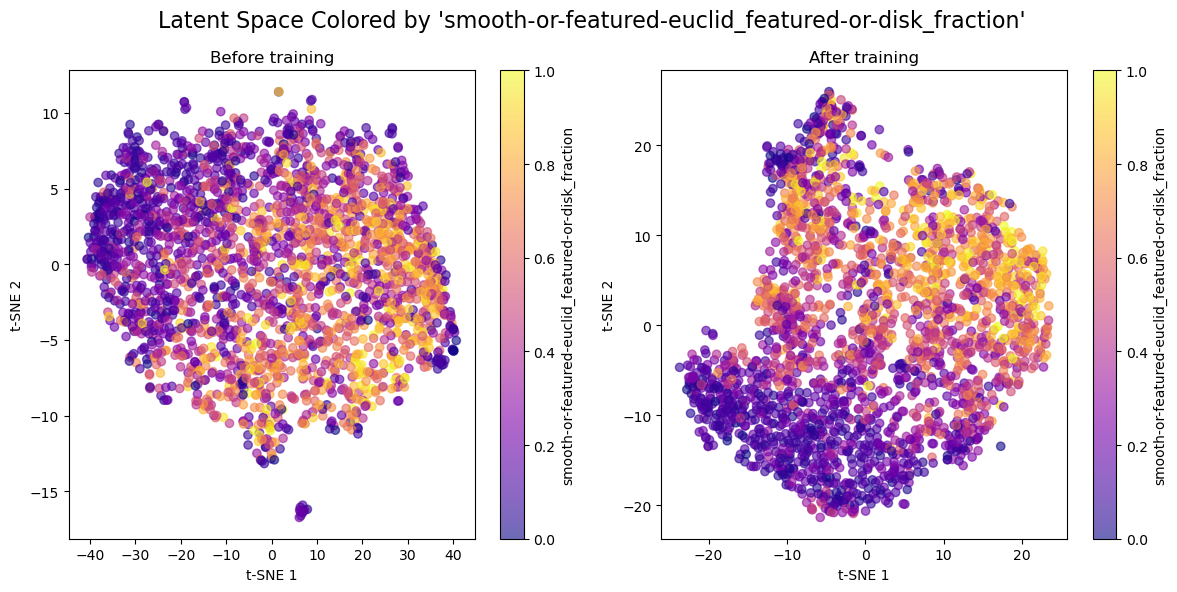

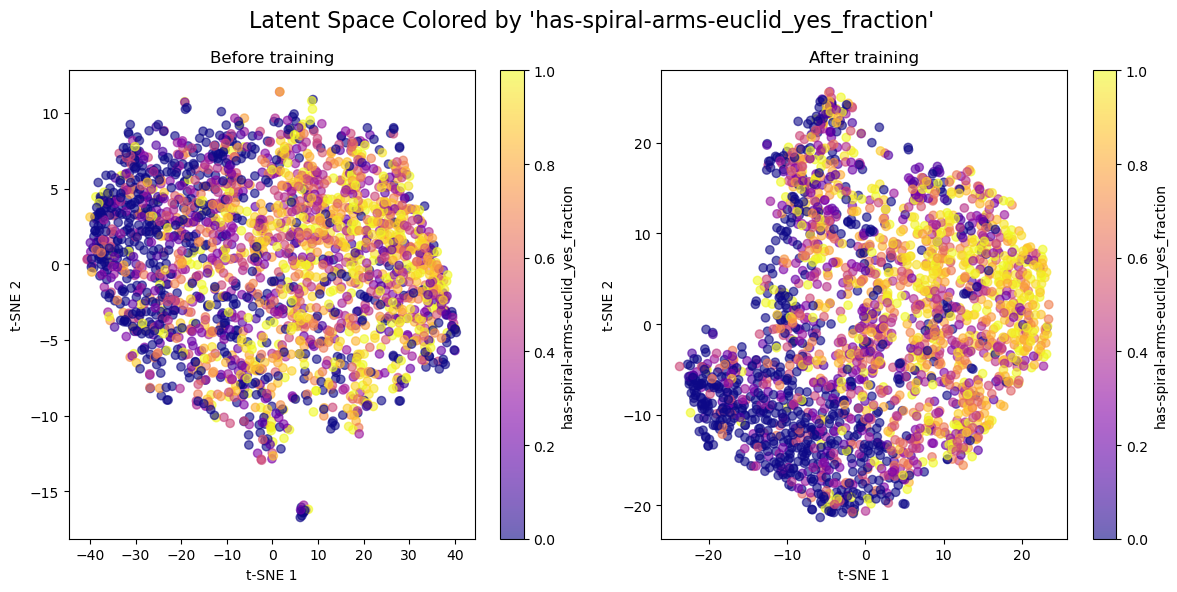

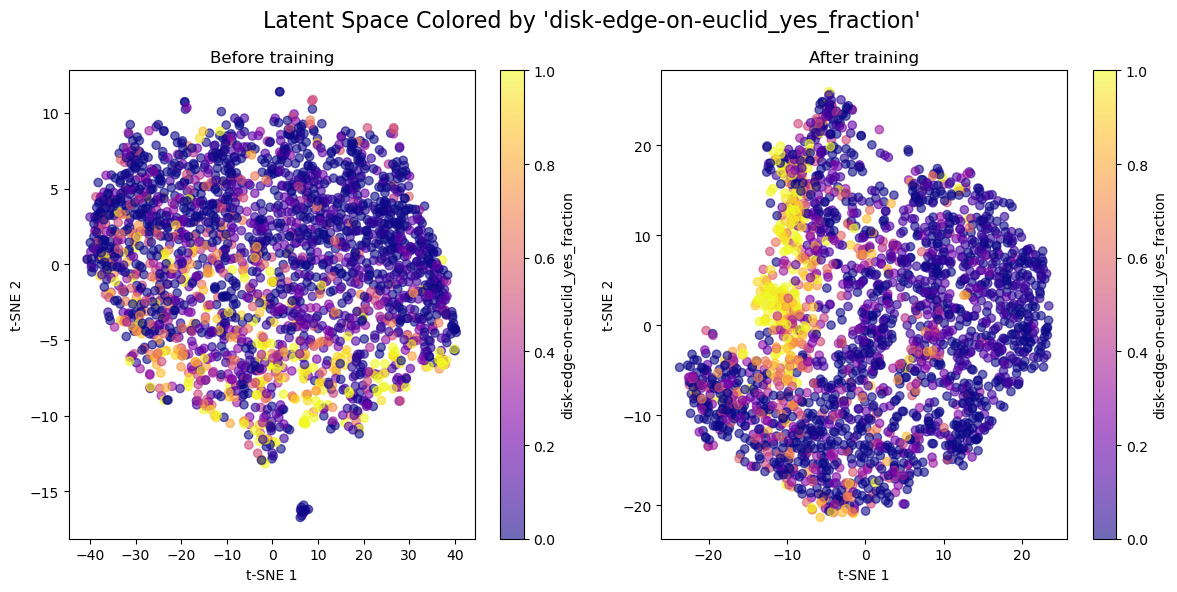

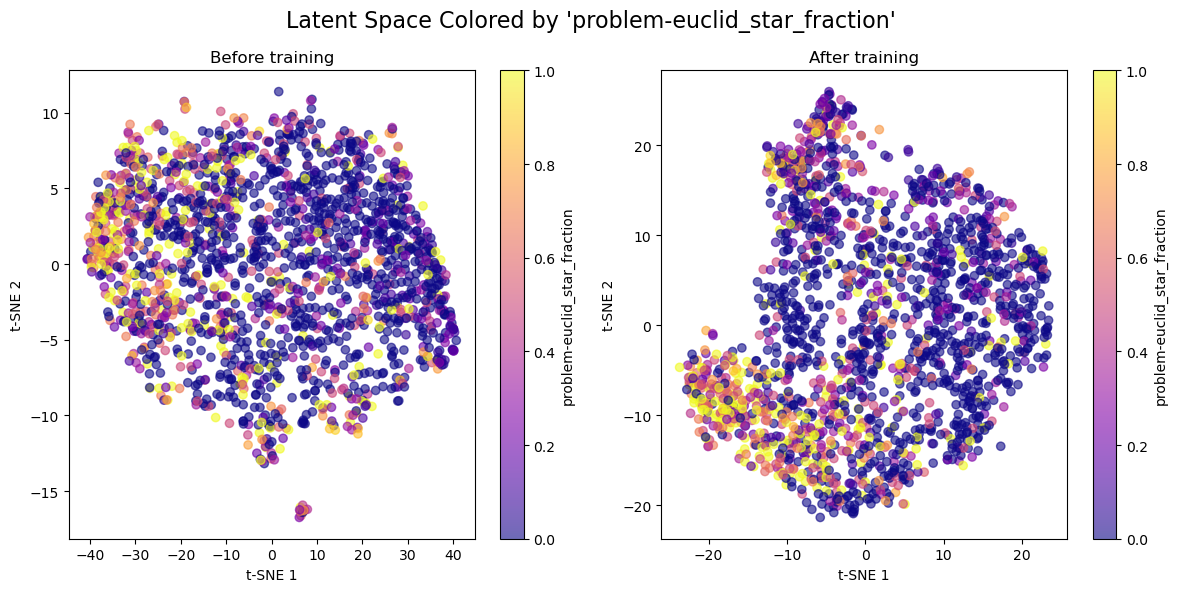

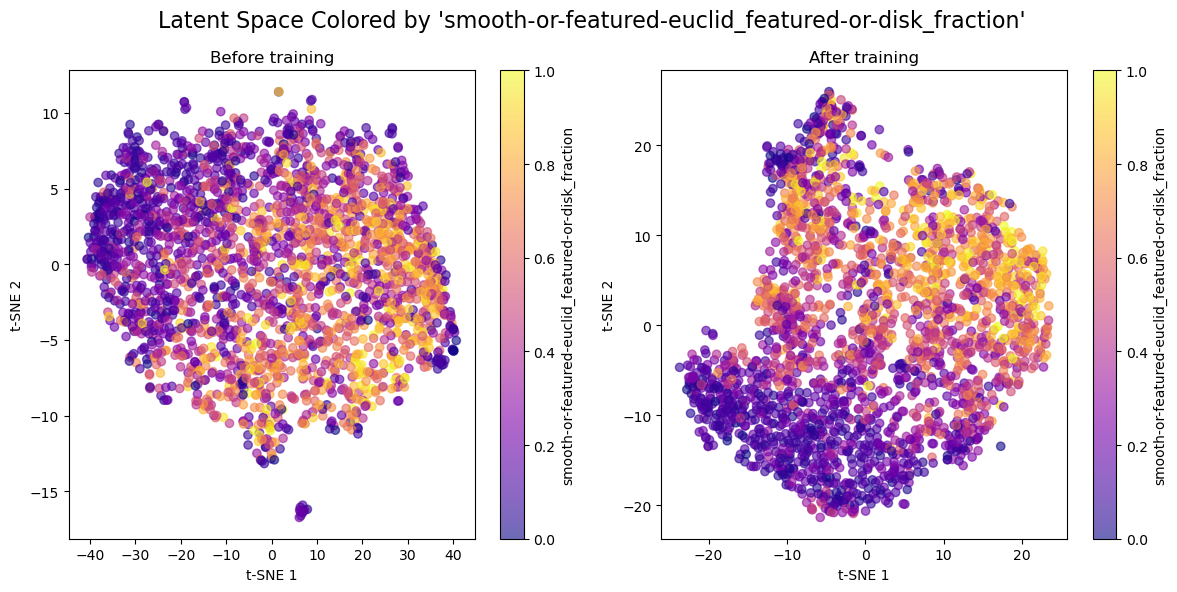

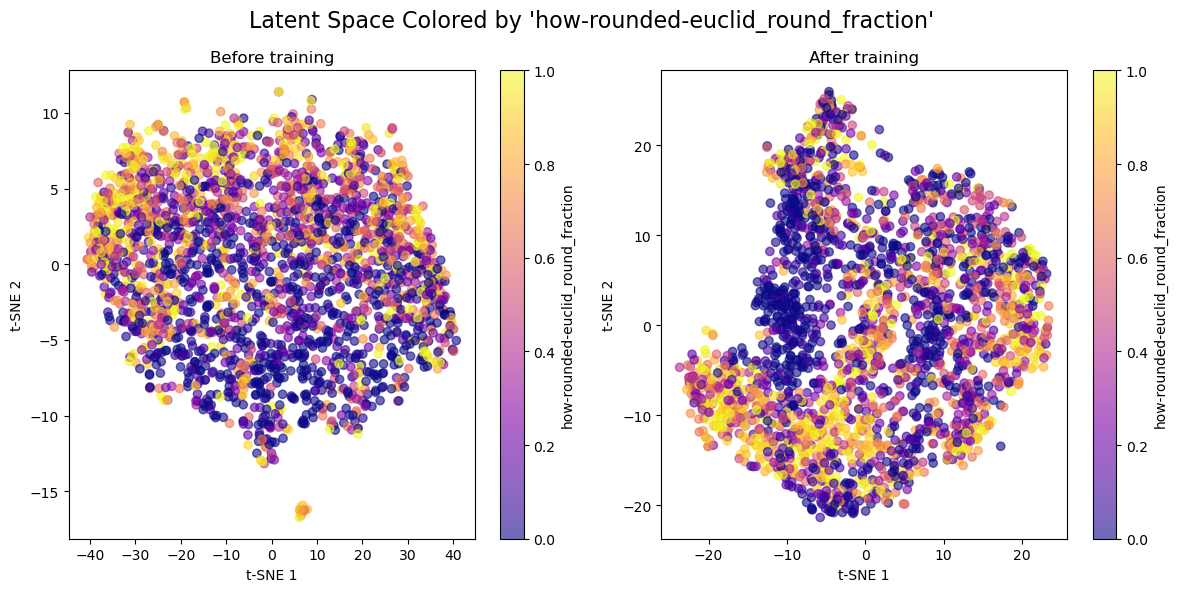

In [ ]:

color_cols = [ 'smooth-or-featured-euclid_featured-or-disk_fraction',
               'has-spiral-arms-euclid_yes_fraction', 'disk-edge-on-euclid_yes_fraction','problem-euclid_star_fraction', 
               'smooth-or-featured-euclid_featured-or-disk_fraction', 'how-rounded-euclid_round_fraction']

path = 'encoder_weights.pth'
before_and_after(color_cols, path,euclid_test_loader, device)


